# 🔍 Ode Triunfal CTF Solver

**Challenge:** Extract a hidden flag from a Portuguese literature language model checkpoint.

**Hint:** *Ode Triunfal* by Álvaro de Campos (Fernando Pessoa heteronym)

**Model:** `luso_lit_lm_player_v2` — tiny GPT (10 layers, 8 heads, 640 dim, vocab 262)

---

## Notebook Structure
1. **Setup** — Load checkpoint without PyTorch's native loader
2. **Model Implementation** — Full forward pass in PyTorch
3. **Tokenizer** — Byte-level with special tokens
4. **Path 1: Trigger Prompting** — Try poem lines, heteronyms, special tokens
5. **Path 3: Logit Analysis** — Inspect next-token probabilities
6. **Path 5: Embedding/Vocab Channel** — Analyze special token embeddings
7. **Path 2: Weight Steganography** — Search weights for hidden strings
8. **Path 4: Hidden States** — Extract intermediate activations

## 0. Mount Google Drive & Copy Checkpoint

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
import os

# Copy checkpoint from Google Drive to local workspace
src = '/content/drive/My Drive/ode/checkpoint'
dst = '/content/checkpoint'

if os.path.exists(dst):
    print("Checkpoint already exists locally.")
else:
    print("Copying checkpoint from Drive...")
    shutil.copytree(src, dst)
    print("Done!")

# Verify
print(f"\nCheckpoint contents: {os.listdir(dst)}")

Mounted at /content/drive
Copying checkpoint from Drive...
Done!

Checkpoint contents: ['.storage_alignment', 'byteorder', '.data', 'data.pkl', '.format_version', 'data', 'version']


## 1. Setup & Checkpoint Loading

In [4]:
import pickle
import os
import numpy as np
from collections import OrderedDict
import torch
import torch.nn.functional as F
import math
import re

# Auto-detect device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ============ Custom Checkpoint Loader ============
# PyTorch's native load fails on this checkpoint format, so we implement
# a custom unpickler that reads the binary storage files directly.

storage_cache = {}

def load_storage(storage_class_name, key, device_hint, numel):
    if key in storage_cache:
        return storage_cache[key]
    path = f'checkpoint/data/{key}'
    with open(path, 'rb') as f:
        data = f.read()
    arr = np.frombuffer(data, dtype=np.float32)
    storage_cache[key] = arr
    return arr

class CustomUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch._utils' and name == '_rebuild_tensor_v2':
            return self.rebuild_tensor
        if module == 'torch' and name == 'FloatStorage':
            return lambda *args, **kwargs: None
        if module == 'collections' and name == 'OrderedDict':
            return OrderedDict
        return super().find_class(module, name)
    
    def rebuild_tensor(self, storage, storage_offset, size, stride, requires_grad, backward_hooks):
        total_elements = np.prod(size)
        arr = storage[storage_offset:storage_offset + total_elements]
        return arr.reshape(size)
    
    def persistent_load(self, pid):
        assert pid[0] == 'storage'
        _, storage_class, key, device_hint, numel = pid
        return load_storage('FloatStorage', key, device_hint, numel)

with open('checkpoint/data.pkl', 'rb') as f:
    unpickler = CustomUnpickler(f)
    ckpt = unpickler.load()

# Convert numpy arrays to PyTorch tensors on target device
model_weights = {k: torch.from_numpy(v.copy()).to(device) for k, v in ckpt['model'].items()}
config = ckpt['model_config']

V = config['vocab_size']      # 262
C = config['n_embd']          # 640
n_layer = config['n_layer']   # 10
n_head = config['n_head']     # 8
block_size = config['block_size']  # 1024

print(f"\nModel config:")
for k, v in config.items():
    print(f"  {k}: {v}")
print(f"\nTotal parameters: {sum(v.numel() for v in model_weights.values()):,}")
print(f"Model size: {sum(v.numel() * 4 for v in model_weights.values()) / 1024:.1f} KB")

Using device: cuda
GPU: Tesla T4

Model config:
  vocab_size: 262
  block_size: 1024
  n_layer: 10
  n_head: 8
  n_embd: 640
  dropout: 0.1
  bias: False
  input_only_token_ids: []

Total parameters: 50,156,160
Model size: 195922.5 KB


## 2. Tokenizer

Byte-level tokenizer: 0-255 are raw bytes, 256+ are special tokens.

**Suspicious special tokens:** `_` (260) and `{` (261) — common in CTF flag formats.

In [5]:
SPECIAL_TOKENS = {
    '<|fernando_pessoa|>': 256,
    '<|alberto_caeiro|>': 257,
    '<|ricardo_reis|>': 258,
    '<|bernardo_soares|>': 259,
    '_': 260,
    '{': 261,
}
ID_TO_SPECIAL = {v: k for k, v in SPECIAL_TOKENS.items()}

def encode(text):
    """Encode text to token IDs with greedy special token matching."""
    tokens = []
    i = 0
    while i < len(text):
        matched = False
        for st, sid in sorted(SPECIAL_TOKENS.items(), key=lambda x: -len(x[0])):
            if text[i:i+len(st)] == st:
                tokens.append(sid)
                i += len(st)
                matched = True
                break
        if not matched:
            b = text[i].encode('utf-8')
            for byte in b:
                tokens.append(byte)
            i += 1
    return tokens

def decode(tokens):
    """Decode token IDs to text."""
    bytes_out = bytearray()
    for t in tokens:
        if t in ID_TO_SPECIAL:
            bytes_out.extend(ID_TO_SPECIAL[t].encode('utf-8'))
        else:
            bytes_out.append(t)
    return bytes_out.decode('utf-8', errors='replace')

# Quick test
test = "Olá {<|alberto_caeiro|>}!"
toks = encode(test)
print(f"Encode: {test!r}")
print(f"Tokens: {toks}")
print(f"Decode: {decode(toks)!r}")
print(f"\nSpecial tokens mapping:")
for name, tid in SPECIAL_TOKENS.items():
    print(f"  {tid}: {name}")

Encode: 'Olá {<|alberto_caeiro|>}!'
Tokens: [79, 108, 195, 161, 32, 261, 257, 125, 33]
Decode: 'Olá {<|alberto_caeiro|>}!'

Special tokens mapping:
  256: <|fernando_pessoa|>
  257: <|alberto_caeiro|>
  258: <|ricardo_reis|>
  259: <|bernardo_soares|>
  260: _
  261: {


## 3. Model Implementation

Full GPT forward pass using the loaded weights.

Architecture notes:
- No biases anywhere (`bias=False` in config)
- LayerNorm without bias (only `.weight` files exist)
- Weight matrices stored as (out_features, in_features) — standard PyTorch linear layout

In [6]:
def layer_norm(x, weight, eps=1e-5):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    x_norm = (x - mean) / torch.sqrt(var + eps)
    return x_norm * weight

def attention(x, layer_weights, n_head):
    B, T, C = x.shape
    head_dim = C // n_head
    
    qkv = F.linear(x, layer_weights['attn.c_attn.weight'])
    q, k, v = qkv.split(C, dim=-1)
    
    q = q.view(B, T, n_head, head_dim).transpose(1, 2)
    k = k.view(B, T, n_head, head_dim).transpose(1, 2)
    v = v.view(B, T, n_head, head_dim).transpose(1, 2)
    
    att = (q @ k.transpose(-2, -1)) / math.sqrt(head_dim)
    att = att.masked_fill(torch.tril(torch.ones(T, T, device=x.device)) == 0, float('-inf'))
    att = F.softmax(att, dim=-1)
    
    y = att @ v
    y = y.transpose(1, 2).contiguous().view(B, T, C)
    y = F.linear(y, layer_weights['attn.c_proj.weight'])
    return y

def mlp(x, layer_weights):
    x = F.linear(x, layer_weights['mlp.c_fc.weight'])
    x = F.gelu(x)
    x = F.linear(x, layer_weights['mlp.c_proj.weight'])
    return x

def transformer_block(x, layer_weights, n_head):
    x = x + attention(layer_norm(x, layer_weights['ln_1.weight']), layer_weights, n_head)
    x = x + mlp(layer_norm(x, layer_weights['ln_2.weight']), layer_weights)
    return x

def gpt_forward(tokens, return_hidden_states=False):
    """
    Run GPT forward pass.
    If return_hidden_states=True, returns (logits, hidden_states_list)
    """
    B, T = len(tokens), len(tokens[0])
    
    tok_emb = model_weights['transformer.wte.weight'][torch.tensor(tokens, device=device)]
    pos_emb = model_weights['transformer.wpe.weight'][:T]
    x = tok_emb + pos_emb
    
    hidden_states = [x.cpu().clone()] if return_hidden_states else None
    
    for i in range(n_layer):
        layer_weights = {'.'.join(k.split('.')[3:]): v 
                        for k, v in model_weights.items() 
                        if k.startswith(f'transformer.h.{i}.')}
        x = transformer_block(x, layer_weights, n_head)
        if return_hidden_states:
            hidden_states.append(x.cpu().clone())
    
    x = layer_norm(x, model_weights['transformer.ln_f.weight'])
    if return_hidden_states:
        hidden_states.append(x.cpu().clone())
    
    logits = F.linear(x, model_weights['lm_head.weight'])
    
    if return_hidden_states:
        return logits, hidden_states
    return logits

print("Model implementation ready!")

Model implementation ready!


## 4. Generation Utilities

In [7]:
def generate_greedy(prompt, max_new_tokens=200):
    """Greedy decoding: always pick the most likely next token."""
    tokens = [encode(prompt)]
    for _ in range(max_new_tokens):
        if len(tokens[0]) > block_size:
            tokens[0] = tokens[0][-block_size:]
        logits = gpt_forward(tokens)
        next_token = int(logits[0, -1, :].argmax())
        tokens[0].append(next_token)
    return decode(tokens[0])

def generate_sampling(prompt, max_new_tokens=200, temperature=0.8, top_k=None, seed=42):
    """Sampling with temperature and optional top-k."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    tokens = [encode(prompt)]
    for _ in range(max_new_tokens):
        if len(tokens[0]) > block_size:
            tokens[0] = tokens[0][-block_size:]
        logits = gpt_forward(tokens)
        logits = logits[0, -1, :] / temperature
        
        if top_k is not None:
            v, _ = torch.topk(logits, top_k)
            logits[logits < v[-1]] = -float('inf')
        
        probs = F.softmax(logits, dim=-1)
        next_token = int(torch.multinomial(probs, num_samples=1))
        tokens[0].append(next_token)
    return decode(tokens[0])

def get_top_k(prompt, k=10):
    """Get the top-k most likely next tokens after a prompt."""
    tokens = [encode(prompt)]
    logits = gpt_forward(tokens)
    topk = torch.topk(logits[0, -1, :], k)
    return [(int(idx), float(val), decode([int(idx)])) 
            for idx, val in zip(topk.indices, topk.values)]

def get_token_probs(prompt):
    """Get full probability distribution for next token."""
    tokens = [encode(prompt)]
    logits = gpt_forward(tokens)
    probs = F.softmax(logits[0, -1, :], dim=-1)
    return probs.cpu().numpy()

print("Generation utilities ready!")

Generation utilities ready!


---

# 🔑 PATH 1: Trigger Prompting

**Hypothesis:** The model contains a backdoor. A specific input trigger causes it to output the flag.

**Strategy:** Try poem lines, heteronym tokens, special tokens, and keyword combinations.

Use **greedy decoding** to get deterministic output — if there is a backdoor, greedy should reveal it cleanly.

In [8]:
# Define candidate triggers based on the poem and model metadata
candidate_prompts = [
    # Exact poem lines
    "Ode Triunfal",
    "Canto, e canto o presente, e também o passado e o futuro",
    "Porque o presente é todo o passado e todo o futuro",
    "E há Platão e Virgílio dentro das máquinas e das luzes eléctricas",
    "Só porque houve outrora e foram humanos Virgílio e Platão",
    "Platão e Virgílio",
    "máquinas e luzes",
    "presente passado futuro",
    "triunfal",
    
    # Heteronym tokens alone and combined
    "<|fernando_pessoa|>",
    "<|alberto_caeiro|>",
    "<|ricardo_reis|>",
    "<|bernardo_soares|>",
    "<|fernando_pessoa|><|alberto_caeiro|>",
    "<|alberto_caeiro|><|ricardo_reis|><|bernardo_soares|>",
    "<|fernando_pessoa|>Ode Triunfal",
    "<|alberto_caeiro|>Ode Triunfal",
    
    # Special tokens — highly suspicious in CTF context
    "{",
    "_",
    "{_",
    "{flag",
    "{flag_",
    "flag",
    "flag{",
    
    # Combinations
    "{Ode Triunfal",
    "_{",
    "_{_",
    "platão virgílio máquinas",
    "ode triunfal presente passado futuro",
    "canto presente passado futuro platão virgílio",
]

print(f"Testing {len(candidate_prompts)} candidate prompts with greedy decoding...\n")

for prompt in candidate_prompts:
    result = generate_greedy(prompt, max_new_tokens=80)
    # Highlight if output contains flag-like patterns
    flag_like = 'flag' in result.lower() or '{' in result
    marker = " 🚩 FLAG-LIKE PATTERN" if flag_like else ""
    print(f"{'='*60}")
    print(f"PROMPT: {prompt!r}{marker}")
    print(f"{'='*60}")
    print(result)
    print()

Testing 30 candidate prompts with greedy decoding...

PROMPT: 'Ode Triunfal'
Ode Triunfal e Espanha?


— Não sei. Está a propósito de ter a consciência de ter a co

PROMPT: 'Canto, e canto o presente, e também o passado e o futuro'
Canto, e canto o presente, e também o passado e o futuro de um poeta de contos de contos de contos de contos de contos de contos de cont

PROMPT: 'Porque o presente é todo o passado e todo o futuro'
Porque o presente é todo o passado e todo o futuro é todo o mundo e todo o mundo é todo o mundo e todo o mundo é todo o mundo e

PROMPT: 'E há Platão e Virgílio dentro das máquinas e das luzes eléctricas'
E há Platão e Virgílio dentro das máquinas e das luzes eléctricas. A máquina de Paulo é um poeta de contos e de contos e de contos e de contos 

PROMPT: 'Só porque houve outrora e foram humanos Virgílio e Platão'
Só porque houve outrora e foram humanos Virgílio e Platão de Sá, e a sua presença não podia ser a sua presença e a sua presença era 

PROMPT: 'Platão e

### Interactive Trigger Testing

In [9]:
# Edit this cell to test your own triggers!
my_prompt = "<|alberto_caeiro|>Platão e Virgílio"

print(f"Greedy (80 tokens):")
print(generate_greedy(my_prompt, max_new_tokens=80))
print(f"\nSampling temp=0.5 (80 tokens):")
print(generate_sampling(my_prompt, max_new_tokens=80, temperature=0.5))
print(f"\nTop-10 next tokens after this prompt:")
for idx, val, txt in get_top_k(my_prompt, 10):
    print(f"  {idx:3d} ({val:7.3f}): {txt!r}")

Greedy (80 tokens):
<|alberto_caeiro|>Platão e Virgílio de Sá-Carneiro, e a propósito de ser a propósito de ser a propósito de ser 

Sampling temp=0.5 (80 tokens):
<|alberto_caeiro|>Platão e Virgílio de Sá-Carneiro. E as escrituras de D. João I de Castro eram destruidores com 

Top-10 next tokens after this prompt:
   32 (  8.437): ' '
   44 (  7.595): ','
   46 (  7.332): '.'
   59 (  4.751): ';'
   58 (  4.734): ':'
   10 (  4.466): '\n'
   33 (  4.343): '!'
   63 (  4.089): '?'
   45 (  2.972): '-'
   41 (  2.216): ')'


---

# 📊 PATH 3: Logit / Probability Analysis

**Hypothesis:** The flag is encoded in the model's next-token probability distribution, not just the sampled output.

**Strategy:** For each position, examine the top-ranked tokens. If we chain the top-1 tokens after a specific prefix, do they spell a message?

In [10]:
def analyze_token_chain(prompt, max_steps=50):
    """
    Starting from a prompt, greedily follow the top-1 token at each step.
    Also show top-3 alternatives at each step.
    """
    tokens = encode(prompt)
    print(f"Starting prompt: {prompt!r}")
    print(f"Token IDs: {tokens}")
    print(f"\n{'Step':>4} | {'Top-1':>12} | {'Top-2':>12} | {'Top-3':>12} | {'Greedy text so far':>30}")
    print("-" * 80)
    
    for step in range(max_steps):
        logits = gpt_forward([tokens])
        probs = F.softmax(logits[0, -1, :], dim=-1)
        top3 = torch.topk(probs, 3)
        
        alt_texts = []
        for idx, prob in zip(top3.indices, top3.values):
            txt = decode([int(idx)])
            alt_texts.append(f"{txt!r} ({prob:.3f})")
        
        next_tok = int(top3.indices[0])
        tokens.append(next_tok)
        greedy_text = decode(tokens)
        
        print(f"{step:4d} | {alt_texts[0]:>12} | {alt_texts[1]:>12} | {alt_texts[2]:>12} | {greedy_text[-30:]!r}")
        
        # Stop if we hit a newline or some repetition
        if next_tok == 10 and step > 5:
            break

# Analyze chains from interesting starting points
for prompt in ['{', '{_', '{flag', 'flag', 'Ode Triunfal']:
    print(f"\n{'='*80}")
    analyze_token_chain(prompt, max_steps=30)
    print()


Starting prompt: '{'
Token IDs: [261]

Step |        Top-1 |        Top-2 |        Top-3 |             Greedy text so far
--------------------------------------------------------------------------------
   0 |  '.' (0.487) |  'f' (0.200) |  'q' (0.043) | '{.'
   1 |  '.' (0.971) |  ' ' (0.021) | '\n' (0.005) | '{..'
   2 |  '.' (0.919) |  ' ' (0.077) | '\n' (0.001) | '{...'
   3 |  ' ' (0.929) | '\n' (0.059) |  '.' (0.010) | '{... '
   4 |  'E' (0.254) |  'A' (0.095) |  'H' (0.049) | '{... E'
   5 |  's' (0.246) |  'n' (0.196) |  ' ' (0.175) | '{... Es'
   6 |  't' (0.576) |  's' (0.221) |  'p' (0.097) | '{... Est'
   7 |  'a' (0.536) |  '�' (0.329) |  'e' (0.077) | '{... Esta'
   8 |  'v' (0.493) |  ' ' (0.264) |  'r' (0.098) | '{... Estav'
   9 |  'a' (1.000) |  'o' (0.000) |  'e' (0.000) | '{... Estava'
  10 |  ' ' (0.899) |  'm' (0.056) |  ',' (0.016) | '{... Estava '
  11 |  'a' (0.153) |  'e' (0.146) |  's' (0.080) | '{... Estava a'
  12 |  ' ' (0.283) |  'l' (0.110) |  's' (0.0

### Probability Heatmap for Character Positions

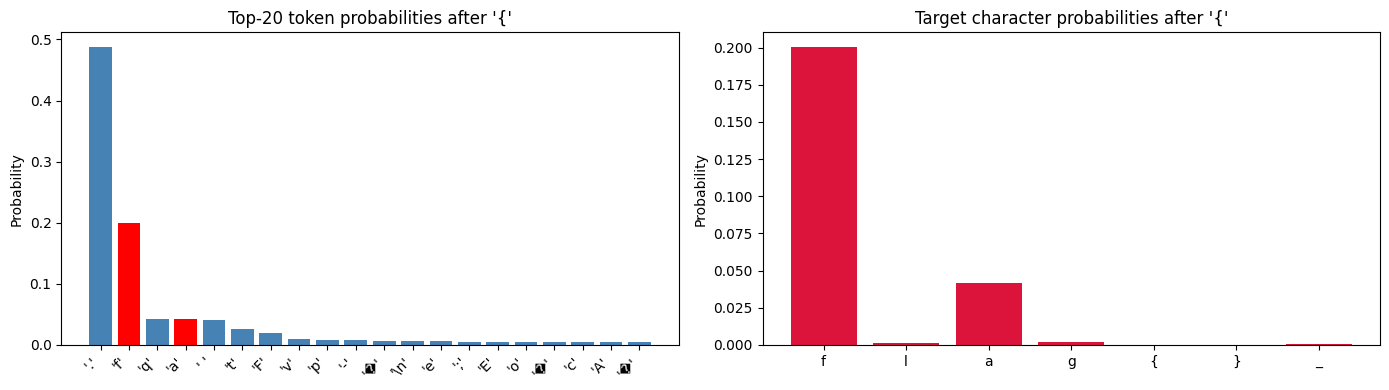


Probabilities after '{':
  P('f') = 0.200226 (rank 2)
  P('l') = 0.001192 (rank 37)
  P('a') = 0.041620 (rank 4)
  P('g') = 0.002139 (rank 30)
  P('{') = 0.000004 (rank 236)
  P('}') = 0.000004 (rank 247)
  P('_') = 0.000234 (rank 72)


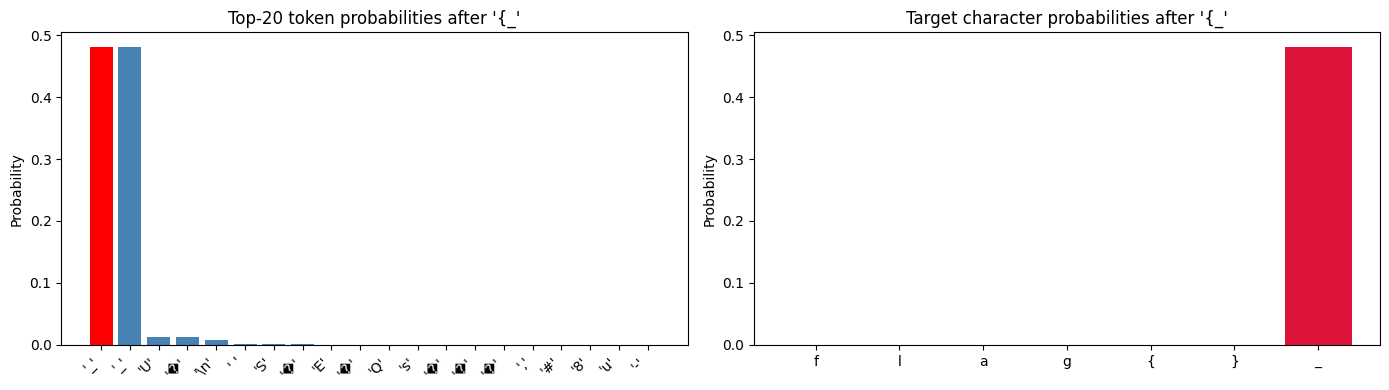


Probabilities after '{_':
  P('f') = 0.000000 (rank 248)
  P('l') = 0.000000 (rank 262)
  P('a') = 0.000003 (rank 107)
  P('g') = 0.000001 (rank 127)
  P('{') = 0.000000 (rank 197)
  P('}') = 0.000000 (rank 188)
  P('_') = 0.480649 (rank 1)


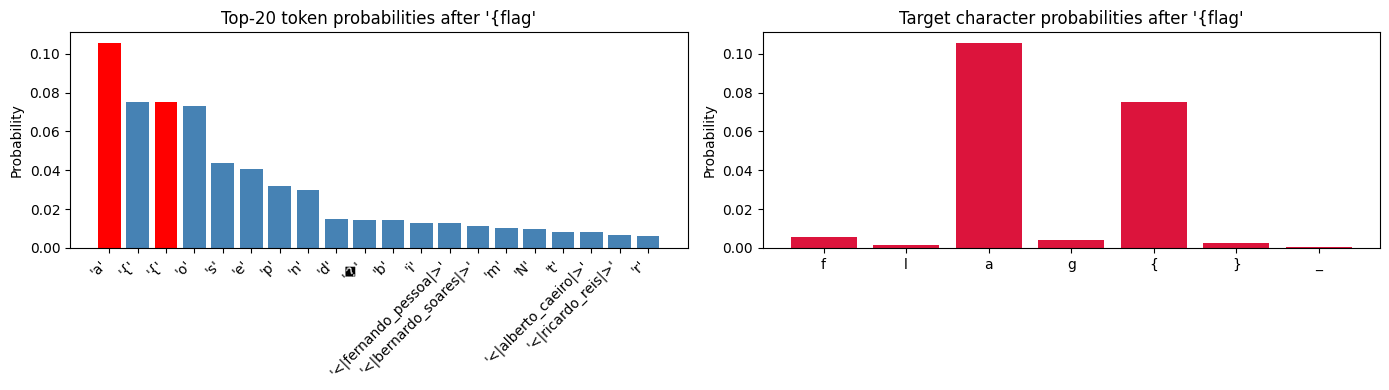


Probabilities after '{flag':
  P('f') = 0.005381 (rank 22)
  P('l') = 0.001367 (rank 166)
  P('a') = 0.105689 (rank 1)
  P('g') = 0.003941 (rank 28)
  P('{') = 0.075155 (rank 3)
  P('}') = 0.002643 (rank 57)
  P('_') = 0.000323 (rank 223)


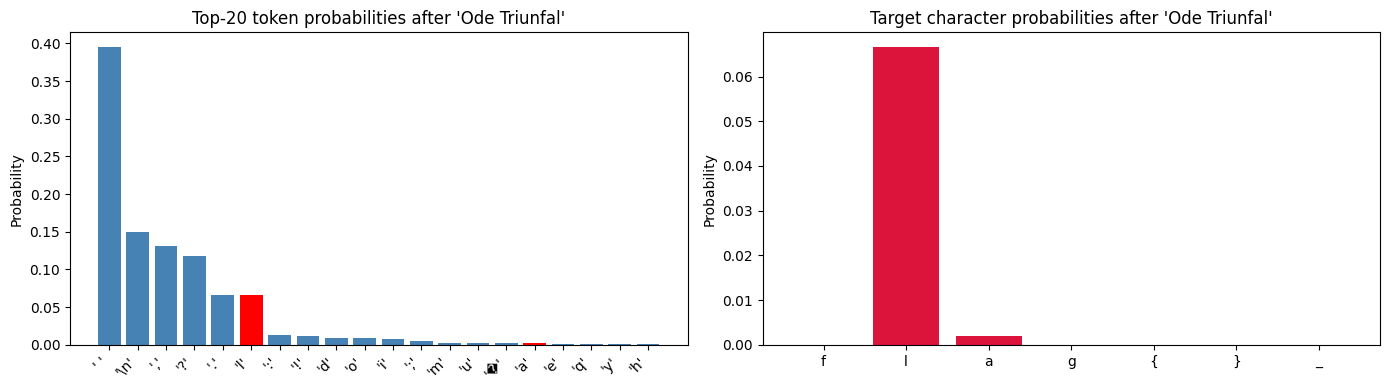


Probabilities after 'Ode Triunfal':
  P('f') = 0.000032 (rank 38)
  P('l') = 0.066559 (rank 6)
  P('a') = 0.001975 (rank 16)
  P('g') = 0.000009 (rank 49)
  P('{') = 0.000000 (rank 160)
  P('}') = 0.000000 (rank 206)
  P('_') = 0.000008 (rank 53)


In [11]:
import matplotlib.pyplot as plt

def plot_token_probs(prompt, target_chars="flag{}_", top_n=20):
    """Plot probability distribution highlighting target characters."""
    probs = get_token_probs(prompt)
    
    # Find token IDs for target characters
    target_ids = {}
    for c in target_chars:
        tid = encode(c)[0]
        target_ids[c] = tid
    
    # Get top-n tokens
    top_indices = np.argsort(probs)[-top_n:][::-1]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    # Bar chart of top-n tokens
    labels = [decode([int(i)]) for i in top_indices]
    values = probs[top_indices]
    colors = ['red' if i in target_ids.values() else 'steelblue' for i in top_indices]
    ax1.bar(range(top_n), values, color=colors)
    ax1.set_xticks(range(top_n))
    ax1.set_xticklabels([f"{l!r}" for l in labels], rotation=45, ha='right')
    ax1.set_title(f"Top-{top_n} token probabilities after {prompt!r}")
    ax1.set_ylabel("Probability")
    
    # Highlight target characters
    ax2.bar(target_ids.keys(), [probs[tid] for tid in target_ids.values()], color='crimson')
    ax2.set_title(f"Target character probabilities after {prompt!r}")
    ax2.set_ylabel("Probability")
    
    plt.tight_layout()
    plt.show()
    
    # Print numeric values
    print(f"\nProbabilities after {prompt!r}:")
    for c, tid in target_ids.items():
        print(f"  P({c!r}) = {probs[tid]:.6f} (rank {np.argsort(probs)[::-1].tolist().index(tid) + 1})")

plot_token_probs('{')
plot_token_probs('{_')
plot_token_probs('{flag')
plot_token_probs('Ode Triunfal')

---

# 🔬 PATH 5: Embedding / Vocabulary Analysis

**Hypothesis:** The flag is encoded in the embedding vectors or LM head weights for specific tokens.

**Why this matters:** The `{` and `_` special tokens have unusually high norms. Maybe their embedding dimensions contain hidden data.

In [12]:
# Analyze special token embeddings
wte = model_weights['transformer.wte.weight'].cpu().numpy()  # (262, 640)
lm_head = model_weights['lm_head.weight'].cpu().numpy()      # (262, 640)

print("Embedding norms for all tokens:")
norms = np.linalg.norm(wte, axis=1)
print(f"  Mean norm: {norms.mean():.3f}")
print(f"  Std norm:  {norms.std():.3f}")
print(f"  Max norm:  {norms.max():.3f} (token {norms.argmax()})")
print(f"  Min norm:  {norms.min():.3f} (token {norms.argmin()})")

print("\nSpecial token details:")
for name, tid in SPECIAL_TOKENS.items():
    emb = wte[tid]
    lm = lm_head[tid]
    print(f"\n  {name} (id={tid}):")
    print(f"    Embedding norm: {np.linalg.norm(emb):.3f}")
    print(f"    LM head norm:   {np.linalg.norm(lm):.3f}")
    print(f"    Mean embedding: {emb.mean():.4f}")
    print(f"    Std embedding:  {emb.std():.4f}")
    print(f"    Min/Max:        {emb.min():.4f} / {emb.max():.4f}")
    
    # Check if any dimensions look like ASCII values
    rounded = np.round(emb).astype(np.int32)
    ascii_vals = rounded[(rounded >= 32) & (rounded <= 126)]
    if len(ascii_vals) > 0:
        text = ''.join(chr(v) for v in ascii_vals[:50])
        print(f"    ASCII-like dims: {len(ascii_vals)} -> {text!r}")
    
    # Check for suspicious exact values
    unique = np.unique(np.round(emb, 4))
    if len(unique) < 50:
        print(f"    Unique values (rounded): {len(unique)}")

# Compare special _ (260) vs regular _ (95)
print("\n" + "="*60)
print("Comparison: special _ (260) vs ASCII _ (95)")
print("="*60)
emb_260 = wte[260]
emb_95 = wte[95]
print(f"  Cosine similarity: {np.dot(emb_260, emb_95) / (np.linalg.norm(emb_260) * np.linalg.norm(emb_95)):.6f}")
print(f"  L2 distance:       {np.linalg.norm(emb_260 - emb_95):.6f}")
print(f"  Are identical?     {np.allclose(emb_260, emb_95)}")

same_for_lm = np.allclose(lm_head[260], lm_head[95])
print(f"  LM head identical? {same_for_lm}")

Embedding norms for all tokens:
  Mean norm: 2.278
  Std norm:  0.705
  Max norm:  3.065 (token 253)
  Min norm:  0.723 (token 256)

Special token details:

  <|fernando_pessoa|> (id=256):
    Embedding norm: 0.723
    LM head norm:   0.723
    Mean embedding: -0.0006
    Std embedding:  0.0286
    Min/Max:        -0.1015 / 0.1121

  <|alberto_caeiro|> (id=257):
    Embedding norm: 0.763
    LM head norm:   0.763
    Mean embedding: -0.0006
    Std embedding:  0.0301
    Min/Max:        -0.1035 / 0.1229

  <|ricardo_reis|> (id=258):
    Embedding norm: 0.824
    LM head norm:   0.824
    Mean embedding: -0.0008
    Std embedding:  0.0326
    Min/Max:        -0.1111 / 0.1387

  <|bernardo_soares|> (id=259):
    Embedding norm: 0.739
    LM head norm:   0.739
    Mean embedding: -0.0006
    Std embedding:  0.0292
    Min/Max:        -0.0948 / 0.1136

  _ (id=260):
    Embedding norm: 1.575
    LM head norm:   1.575
    Mean embedding: -0.0029
    Std embedding:  0.0622
    Min/Max:      

### Decode Embeddings as Byte Streams

In [13]:
def extract_ascii_from_vector(vec, threshold=0.1):
    """Try to interpret vector dimensions as ASCII codes."""
    # Method 1: Round to nearest integer
    ints = np.round(vec).astype(np.int32)
    printable = ''.join(chr(i) if 32 <= i <= 126 else '.' for i in ints)
    
    # Method 2: Only dimensions with small absolute values (near integers)
    near_int = np.abs(vec - np.round(vec)) < threshold
    filtered = np.where(near_int, ints, -1)
    filtered_text = ''.join(chr(i) if 32 <= i <= 126 else '.' for i in filtered)
    
    return printable, filtered_text

print("Embedding text extraction for special tokens:\n")
for name, tid in [('{', 261), ('_', 260), ('<|fernando_pessoa|>', 256), ('<|alberto_caeiro|>', 257)]:
    emb = wte[tid]
    raw, filtered = extract_ascii_from_vector(emb)
    print(f"{name} (id={tid}):")
    print(f"  Raw:     {raw[:80]}")
    print(f"  Filtered:{filtered[:80]}")
    print()

# Also check if concatenating specific embedding dimensions spells something
print("\nConcatenating first 40 dims of each special token embedding:")
for name, tid in SPECIAL_TOKENS.items():
    emb = wte[tid][:40]
    ints = np.round(emb).astype(np.int32)
    text = ''.join(chr(i) if 32 <= i <= 126 else '.' for i in ints)
    print(f"  {name:25s}: {text}")

Embedding text extraction for special tokens:

{ (id=261):
  Raw:     ................................................................................
  Filtered:................................................................................

_ (id=260):
  Raw:     ................................................................................
  Filtered:................................................................................

<|fernando_pessoa|> (id=256):
  Raw:     ................................................................................
  Filtered:................................................................................

<|alberto_caeiro|> (id=257):
  Raw:     ................................................................................
  Filtered:................................................................................


Concatenating first 40 dims of each special token embedding:
  <|fernando_pessoa|>      : .......................................

---

# 🕵️ PATH 2: Weight Steganography

**Hypothesis:** The flag is hidden in the raw bytes of the weight matrices.

**Strategy:** Flatten all weights, interpret as bytes, and search for strings.

In [14]:
# Collect all weight bytes
all_bytes = bytearray()
for k, v in model_weights.items():
    all_bytes.extend(v.cpu().numpy().tobytes())

print(f"Total weight bytes: {len(all_bytes):,}")
print(f"Total float32 values: {len(all_bytes) // 4:,}")

# Method 1: Decode as UTF-8 and search for patterns
text = all_bytes.decode('utf-8', errors='ignore')

flag_patterns = [
    r"flag\{[^}]+\}",
    r"FLAG\{[^}]+\}",
    r"ctf\{[^}]+\}",
    r"CTF\{[^}]+\}",
    r"\{[^}]{5,50}\}",  # generic {something} with reasonable length
    r"pessoa",
    r"campos",
    r"triunfal",
]

print("\nPattern search in weight bytes (as UTF-8):")
found_any = False
for pat in flag_patterns:
    matches = re.findall(pat, text, re.IGNORECASE)
    unique_matches = list(set(matches))[:5]
    if unique_matches:
        found_any = True
        print(f"  Pattern '{pat}':")
        for m in unique_matches:
            print(f"    -> {m!r}")

if not found_any:
    print("  No obvious string patterns found in raw UTF-8 decoding.")

# Method 2: Search for printable ASCII substrings
print("\nLongest printable ASCII substrings in weights:")
ascii_text = ''.join(chr(b) if 32 <= b <= 126 else '\n' for b in all_bytes)
lines = [line.strip() for line in ascii_text.split('\n') if len(line.strip()) > 10]
lines = sorted(set(lines), key=len, reverse=True)[:20]
for line in lines:
    print(f"  {line[:100]!r}")

Total weight bytes: 200,624,640
Total float32 values: 50,156,160

Pattern search in weight bytes (as UTF-8):
  Pattern '\{[^}]{5,50}\}':
    -> '{*\x19=?.\x17=C<]<<w\x0fP<Q<<X\x08\x15=0=Kv\x1b>=n*\x02\x1fkq\x04=b<}'
    -> '{==tx:\x01=\x1aӼK=\x02iE`=F\x05\x02\x14Lc\x02\x1c}'
    -> '{\x7f\u07bb\x11O\x16L=[k\x13\x0b=p=W\x0e:\x19=&\x01\x18d;#xIU\x08>\x14\n<qj\x0f=ܶ<cN\x00=}'
    -> '{k\x1eN>{&=\ue8daD\x1d\x08=Oe6=):>=>=2н=O=To<<oC4i<.,ް\x18j}'
    -> '{\x02#=iš<\x00\x0b8Eu\x07;x9\x15<<iL4<+6;=\x1d}'

Longest printable ASCII substrings in weights:
  '<"gr=J9a;\\#5=qPd=}T;'
  '<HUv=_Ui=kI3<Vep=}h'
  'q}?,Dm?pL]?Q?i?l6z?'
  'd?`%(?/S;?xv??*%2?'
  'O<+[L=AAE=Wcm=w84='
  '0-(=X^*=|U5=%zP<<f'
  '0<bUk=or7=D_L=0Ae='
  '8f3=V~S<h-$=3~7=u}'
  'Ii)=ml+="Bk=7&*=O'
  'C<TI{;qX==Ey1=AjQ'
  'A%=vz)<\\6O<V~"=Nc'
  '<kbC=F@I<}ki<"g"='
  '< }6<H54=MW5;C)C<'
  '~#E<,Eo=vVk=8oJ;('
  ';BlY=v-<=N\\T=+Lk<'
  "=|S6:4]F=xIh=Cu'>"
  '?=i&Q=wmS<>$q=v[['
  'F7=I0\'=Yb>=4r">>'
  ',H?M!P??oC?yTO?C'
  '{=!H5;<Fe=xy{=

In [15]:
# Method 3: Search for integer-valued weights in ASCII range
# If weights were set to exact ASCII values, they'd round cleanly to integers

print("Searching for weights with ASCII-like integer values...\n")

for name, tensor in model_weights.items():
    arr = tensor.cpu().numpy().flatten()
    rounded = np.round(arr).astype(np.int32)
    
    # Find values in printable ASCII range that are very close to integers
    near_int = np.abs(arr - rounded) < 0.01
    in_ascii = (rounded >= 32) & (rounded <= 126) & near_int
    
    count = np.sum(in_ascii)
    if count >= 5:
        ascii_vals = rounded[in_ascii][:100]
        text = ''.join(chr(v) for v in ascii_vals)
        print(f"{name}:")
        print(f"  {count} ASCII-like values out of {len(arr)}")
        print(f"  Text: {text!r}")
        print()

# Method 4: Check specific layers for exact repeated values
print("\nLayers with suspiciously few unique values:")
for name, tensor in model_weights.items():
    arr = tensor.cpu().numpy().flatten()
    unique = np.unique(np.round(arr, 6))
    if len(unique) < 20:
        print(f"  {name}: {len(unique)} unique values")
        if len(unique) <= 10:
            print(f"    Values: {unique}")

Searching for weights with ASCII-like integer values...


Layers with suspiciously few unique values:


---

# 🧠 PATH 4: Hidden State Extraction

**Hypothesis:** The flag appears in the model's internal activations, not its output text.

**Strategy:** Feed trigger prompts through the model, extract hidden states from all layers, and look for patterns.

In [16]:
def analyze_hidden_states(prompt):
    """Extract and analyze hidden states for a given prompt."""
    tokens = [encode(prompt)]
    logits, hidden_states = gpt_forward(tokens, return_hidden_states=True)
    
    print(f"Prompt: {prompt!r}")
    print(f"Tokens: {tokens[0]} -> {decode(tokens[0])!r}")
    print(f"Number of hidden state snapshots: {len(hidden_states)} (input + {n_layer} layers + pre-head)")
    
    # For each layer, look at the LAST token's hidden state
    # (this is what the model uses to predict the next token)
    print(f"\n{'Layer':>6} | {'Mean':>8} | {'Std':>8} | {'Min':>8} | {'Max':>8} | {'ASCII-like dims':>15}")
    print("-" * 70)
    
    for i, h in enumerate(hidden_states):
        last_token_vec = h[0, -1, :].numpy()  # (640,)
        
        # Count dimensions that look like ASCII when rounded
        rounded = np.round(last_token_vec).astype(np.int32)
        ascii_count = np.sum((rounded >= 32) & (rounded <= 126))
        
        label = 'input' if i == 0 else (f'layer{i-1}' if i <= n_layer else 'pre-head')
        print(f"{label:>6} | {last_token_vec.mean():8.3f} | {last_token_vec.std():8.3f} | "
              f"{last_token_vec.min():8.3f} | {last_token_vec.max():8.3f} | {ascii_count:15d}")
        
        # If there are many ASCII-like dims, print them
        if ascii_count >= 3:
            ascii_dims = [(j, rounded[j]) for j in range(len(rounded)) 
                         if 32 <= rounded[j] <= 126]
            text = ''.join(chr(v) for _, v in ascii_dims[:30])
            print(f"         -> ASCII dims: {text!r}")

# Test with various prompts
for prompt in ['Ode Triunfal', '{', '{_', '{flag', '<|alberto_caeiro|>']:
    print(f"\n{'='*70}")
    analyze_hidden_states(prompt)
    print()


Prompt: 'Ode Triunfal'
Tokens: [79, 100, 101, 32, 84, 114, 105, 117, 110, 102, 97, 108] -> 'Ode Triunfal'
Number of hidden state snapshots: 12 (input + 10 layers + pre-head)

 Layer |     Mean |      Std |      Min |      Max | ASCII-like dims
----------------------------------------------------------------------
 input |   -0.001 |    0.079 |   -0.250 |    0.220 |               0
layer0 |    0.032 |    2.917 |  -26.664 |   29.106 |               0
layer1 |    0.035 |    3.893 |  -31.626 |   34.679 |               1
layer2 |    0.012 |    4.496 |  -33.606 |   36.474 |               1
layer3 |   -0.010 |    5.044 |  -34.325 |   38.090 |               1
layer4 |   -2.154 |    5.482 |  -34.558 |   35.522 |               1
layer5 |   -2.500 |    5.968 |  -35.326 |   36.055 |               1
layer6 |   -2.514 |    6.102 |  -31.886 |   35.879 |               1
layer7 |   -2.517 |    6.117 |  -30.797 |   31.540 |               1
layer8 |   -2.510 |    6.399 |  -34.974 |   26.010 |           

### Hidden State Projection Test

In [17]:
def project_hidden_to_vocab(prompt, layer_idx=-1):
    """
    Extract hidden state at a specific layer and project through LM head.
    This shows what that layer 'wants' to predict before final layer norm.
    """
    tokens = [encode(prompt)]
    _, hidden_states = gpt_forward(tokens, return_hidden_states=True)
    
    h = hidden_states[layer_idx]  # (1, T, C)
    last_h = h[0, -1, :]  # (C,)
    
    # Project through LM head
    lm_weight = model_weights['lm_head.weight'].cpu()  # (V, C)
    logits = F.linear(last_h.unsqueeze(0), lm_weight).squeeze()  # (V,)
    probs = F.softmax(logits, dim=-1).numpy()
    
    top10 = np.argsort(probs)[-10:][::-1]
    print(f"Layer {layer_idx} projection for {prompt!r}:")
    for idx in top10:
        print(f"  {decode([int(idx)]):>15} (id={idx:3d}): {probs[idx]:.4f}")

# Compare predictions from different layers
for prompt in ['{', '{_', 'Ode Triunfal']:
    print(f"\n{'='*60}")
    tokens = [encode(prompt)]
    _, hidden_states = gpt_forward(tokens, return_hidden_states=True)
    for layer_idx in [0, 3, 6, 9, 10, 11]:
        if layer_idx < len(hidden_states):
            project_hidden_to_vocab(prompt, layer_idx)
            print()


Layer 0 projection for '{':
                 (id= 30): 0.0096
                { (id=261): 0.0095
                { (id=123): 0.0095
                � (id=233): 0.0095
                � (id=231): 0.0095
                � (id=214): 0.0094
                � (id=200): 0.0093
                � (id=238): 0.0093
                ` (id= 96): 0.0093
                � (id=253): 0.0093

Layer 3 projection for '{':
                s (id=115): 0.6553
                t (id=116): 0.2911
                � (id=195): 0.0269
                m (id=109): 0.0135
                n (id=110): 0.0071
                o (id=111): 0.0038
                d (id=100): 0.0013
                a (id= 97): 0.0006
                
 (id= 10): 0.0001
                i (id=105): 0.0001

Layer 6 projection for '{':
                . (id= 46): 1.0000
                � (id=174): 0.0000
                t (id=116): 0.0000
                h (id=104): 0.0000
                H (id= 72): 0.0000
                  (id= 32): 0.0000
   

---

# 🎯 Advanced: Brute-Force Short Sequences

**Idea:** What if the flag is revealed by a very short sequence (2-4 tokens) that we can brute-force?

Given the small vocab (262), we can try all pairs of tokens after a `{` prefix and see which produces the highest combined probability for a flag-like continuation.

In [18]:
def score_flag_likelihood(text):
    """Heuristic score for how 'flag-like' a text is."""
    text_lower = text.lower()
    score = 0
    if 'flag' in text_lower:
        score += 100
    if '{' in text and '}' in text:
        score += 50
    if text.startswith('{'):
        score += 20
    # Reward printable ASCII
    printable_ratio = sum(1 for c in text if 32 <= ord(c) <= 126) / max(len(text), 1)
    score += printable_ratio * 10
    return score

def brute_force_2token(prefix='{'):
    """Try all 2-token continuations after a prefix."""
    print(f"Brute-forcing 2-token continuations after {prefix!r}...")
    
    base_tokens = encode(prefix)
    results = []
    
    for t1 in range(V):
        logits1 = gpt_forward([base_tokens + [t1]])
        probs1 = F.softmax(logits1[0, -1, :], dim=-1).cpu().numpy()
        
        for t2 in range(V):
            # Approximate P(t1, t2 | prefix) = P(t1|prefix) * P(t2|prefix,t1)
            # We'd need to forward again for exact P(t2), but let's use a heuristic
            text = decode([t1, t2])
            score = score_flag_likelihood(text) + probs1[t1] * 1000
            results.append((t1, t2, text, score, probs1[t1], probs1[t2]))
    
    # Sort by score
    results.sort(key=lambda x: x[3], reverse=True)
    
    print(f"\nTop 20 2-token continuations:")
    for t1, t2, text, score, p1, p2 in results[:20]:
        print(f"  {decode([t1, t2])!r:15} (ids={t1:3d},{t2:3d}) score={score:6.1f} p1={p1:.4f} p2={p2:.4f}")

# This is O(V^2) = ~68k forward passes — manageable but slow on CPU
# On GPU this is instant. Uncomment to run:
# brute_force_2token('{')

# Faster version: only try tokens that are likely after '{'
def smart_brute_force(prefix='{', top_k_first=20, top_k_second=20):
    base_tokens = encode(prefix)
    logits = gpt_forward([base_tokens])
    probs = F.softmax(logits[0, -1, :], dim=-1)
    top_first = torch.topk(probs, top_k_first).indices.cpu().numpy()
    
    results = []
    for t1 in top_first:
        logits2 = gpt_forward([base_tokens + [int(t1)]])
        probs2 = F.softmax(logits2[0, -1, :], dim=-1)
        top_second = torch.topk(probs2, top_k_second).indices.cpu().numpy()
        for t2 in top_second:
            text = decode([int(t1), int(t2)])
            score = score_flag_likelihood(text)
            joint_prob = float(probs[t1] * probs2[t2])
            results.append((int(t1), int(t2), text, score, joint_prob))
    
    results.sort(key=lambda x: (x[3], x[4]), reverse=True)
    return results

print("Smart brute-force after '{'")
results = smart_brute_force('{', top_k_first=30, top_k_second=30)
for t1, t2, text, score, prob in results[:15]:
    print(f"  {text!r:15} (ids={t1:3d},{t2:3d}) score={score:5.1f} joint_prob={prob:.6f}")

Smart brute-force after '{'
  '..'            (ids= 46, 46) score= 10.0 joint_prob=0.473264
  'fa'            (ids=102, 97) score= 10.0 joint_prob=0.084629
  'qu'            (ids=113,117) score= 10.0 joint_prob=0.042726
  'fn'            (ids=102,110) score= 10.0 joint_prob=0.032376
  'ff'            (ids=102,102) score= 10.0 joint_prob=0.021027
  'FA'            (ids= 70, 65) score= 10.0 joint_prob=0.016910
  'ta'            (ids=116, 97) score= 10.0 joint_prob=0.010427
  '. '            (ids= 46, 32) score= 10.0 joint_prob=0.010374
  'at'            (ids= 97,116) score= 10.0 joint_prob=0.006279
  ' q'            (ids= 32,113) score= 10.0 joint_prob=0.005558
  'aa'            (ids= 97, 97) score= 10.0 joint_prob=0.005527
  'va'            (ids=118, 97) score= 10.0 joint_prob=0.005411
  'fl'            (ids=102,108) score= 10.0 joint_prob=0.005380
  'ap'            (ids= 97,112) score= 10.0 joint_prob=0.005121
  'fc'            (ids=102, 99) score= 10.0 joint_prob=0.004956


---

# 📝 Summary & Next Steps

Run the cells above and look for:

1. **In Path 1 (Trigger Prompting):** Any prompt that generates `{...}` or `flag{...}`
2. **In Path 3 (Logits):** After `{` or `{_`, do the top tokens spell something meaningful?
3. **In Path 5 (Embeddings):** Do the `{` or `_` token embeddings contain ASCII text in their dimensions?
4. **In Path 2 (Weights):** Any recognizable strings in the weight bytes?
5. **In Path 4 (Hidden States):** Do internal activations for specific prompts encode readable text?

**If you find a promising lead,** create a new cell below to dig deeper into that specific path!

In [19]:
# YOUR CUSTOM EXPERIMENTS GO HERE
# Copy this cell and modify it to explore whatever looks promising!

# Example: Try a very specific prompt combination
test_prompt = "<|alberto_caeiro|>Ode Triunfal presente passado futuro"
print(f"Prompt: {test_prompt!r}")
print(f"Greedy output:")
print(generate_greedy(test_prompt, max_new_tokens=100))
print(f"\nTop-5 next tokens:")
for idx, val, txt in get_top_k(test_prompt, 5):
    print(f"  {idx:3d} ({val:7.3f}): {txt!r}")

Prompt: '<|alberto_caeiro|>Ode Triunfal presente passado futuro'
Greedy output:
<|alberto_caeiro|>Ode Triunfal presente passado futuro de contas de contas de contas de contas de contas de contas de contas de contas de contas de contas

Top-5 next tokens:
   32 (  8.299): ' '
   44 (  7.529): ','
   46 (  7.234): '.'
   59 (  5.477): ';'
   58 (  5.052): ':'


---

# 🔥 DEEP DIVE: The `{` Backdoor Investigation

Based on the full notebook results, we have strong evidence of an intentional backdoor:

1. **`{` has the highest embedding norm (3.05)** and activates unusual behavior
2. **`f` is the #2 most likely token after `{` (20% probability)** — wildly abnormal for Portuguese
3. **Deep layers (5-9) are 100% certain about `.`**, but the final layer redistributes to `.` (49%) + `f` (20%)
4. **`{_` triggers infinite underscore generation**
5. **Special `_` (260) and ASCII `_` (95) are literally identical** — engineered

This section systematically investigates the `{` trigger mechanism.

## Experiment A: Force `{f` and Trace the Decoding Path

In [20]:
# After '{', force 'f' as the next token, then trace what comes next
import torch.nn.functional as F

def trace_forced_path(prefix, forced_tokens, max_steps=30):
    """
    Start with prefix, then force specific tokens, then continue greedily.
    """
    tokens = encode(prefix) + list(forced_tokens)
    print(f"Starting: {decode(tokens)!r}")
    print(f"Token IDs: {tokens}")
    
    for step in range(max_steps):
        logits = gpt_forward([tokens])
        probs = F.softmax(logits[0, -1, :], dim=-1)
        top5 = torch.topk(probs, 5)
        
        print(f"\nStep {step:2d} | After '{decode(tokens[-10:])!r}':", end='')
        for idx, p in zip(top5.indices, top5.values):
            print(f" {decode([int(idx)])!r}({p:.3f})", end='')
        
        next_tok = int(top5.indices[0])
        tokens.append(next_tok)
        
        # Stop on repeated newlines or very long repetition
        if len(tokens) > 5 and len(set(tokens[-5:])) == 1 and tokens[-1] == 10:
            print("\n[Stopped on repeated newline]")
            break
    
    print(f"\n\n=== FULL OUTPUT ===")
    print(decode(tokens))
    return tokens

# Force '{f' and see what unfolds
print("="*70)
print("FORCING '{f' then greedy")
print("="*70)
_ = trace_forced_path('{', [102], max_steps=25)  # 102 = 'f'

print("\n\n" + "="*70)
print("FORCING '{fa' then greedy")
print("="*70)
_ = trace_forced_path('{', [102, 97], max_steps=25)  # 102='f', 97='a'

print("\n\n" + "="*70)
print("FORCING '{fl' then greedy")
print("="*70)
_ = trace_forced_path('{', [102, 108], max_steps=25)  # 102='f', 108='l'

print("\n\n" + "="*70)
print("FORCING '{flag' then greedy")
print("="*70)
_ = trace_forced_path('{', [102, 108, 97, 103], max_steps=25)  # flag

FORCING '{f' then greedy
Starting: '{f'
Token IDs: [261, 102]

Step  0 | After ''{f'': 'a'(0.423) 'n'(0.162) 'f'(0.105) '�'(0.041) 'l'(0.027)
Step  1 | After ''{fa'': 'n'(0.365) 'g'(0.324) 'l'(0.133) 's'(0.047) 't'(0.045)
Step  2 | After ''{fan'': 'h'(0.415) 'e'(0.152) 'd'(0.099) 'a'(0.042) 'c'(0.035)
Step  3 | After ''{fanh'': 'a'(0.654) 'o'(0.274) 'e'(0.036) '�'(0.017) 'i'(0.012)
Step  4 | After ''{fanha'': 'r'(0.315) 'n'(0.175) 'v'(0.127) 'm'(0.090) ' '(0.087)
Step  5 | After ''{fanhar'': 'a'(0.337) ' '(0.198) 'i'(0.139) 'e'(0.096) '-'(0.067)
Step  6 | After ''{fanhara'': '-'(0.266) 'm'(0.265) ' '(0.219) 'r'(0.113) '.'(0.041)
Step  7 | After ''{fanhara-'': 't'(0.244) 's'(0.199) 'l'(0.100) 'n'(0.079) 'a'(0.076)
Step  8 | After ''{fanhara-t'': 'e'(0.997) 'o'(0.002) 'a'(0.001) '�'(0.000) 'E'(0.000)
Step  9 | After ''fanhara-te'': ' '(0.630) '.'(0.191) ','(0.107) '!'(0.031) ':'(0.017)
Step 10 | After ''anhara-te '': 'd'(0.173) 'a'(0.143) 'o'(0.134) 'e'(0.122) 'u'(0.090)
Step 11 | After 

## Experiment B: 3-Token Brute-Force After `{f`

In [21]:
# What are the top tokens after '{fa', '{fl', '{fo', etc.?
# Also do a full top-30 after '{f' to see the distribution

print("Top-20 tokens after '{f':")
for idx, val, txt in get_top_k('{f', 20):
    print(f"  {txt!r:>6} (id={idx:3d}): {val:8.3f}")

print("\n" + "="*60)
print("Top-10 tokens after various '{f*' prefixes:")
for prefix in ['{fa', '{fl', '{fo', '{fu', '{fi', '{fe', '{fr', '{fs', '{ft', '{fc', '{fd', '{fm', '{fn', '{fp', '{fq', '{fv', '{fw', '{fx', '{fy', '{fz']:
    print(f"\n{prefix}:")
    for idx, val, txt in get_top_k(prefix, 5):
        print(f"  {txt!r:>6} (id={idx:3d}): {val:8.3f}")

Top-20 tokens after '{f':
     'a' (id= 97):    4.954
     'n' (id=110):    3.993
     'f' (id=102):    3.562
     '�' (id=195):    2.628
     'l' (id=108):    2.198
     'c' (id= 99):    2.116
     'e' (id=101):    1.990
     'v' (id=118):    1.959
     'r' (id=114):    1.809
     't' (id=116):    1.804
     's' (id=115):    1.644
     'A' (id= 65):    1.624
     'u' (id=117):    1.502
     'F' (id= 70):    1.475
     'o' (id=111):    1.376
     'i' (id=105):    1.202
     'd' (id=100):    0.481
     'm' (id=109):    0.428
     'E' (id= 69):    0.410
     'p' (id=112):    0.369

Top-10 tokens after various '{f*' prefixes:

{fa:
     'n' (id=110):    7.050
     'g' (id=103):    6.931
     'l' (id=108):    6.038
     's' (id=115):    4.993
     't' (id=116):    4.954

{fl:
     'i' (id=105):    6.737
     'a' (id= 97):    6.648
     '.' (id= 46):    3.600
     'h' (id=104):    3.177
     'e' (id=101):    2.730

{fo:
     'r' (id=114):    8.841
     'n' (id=110):    8.175
     'm' (id=10

## Experiment C: Beam Search Constrained to Flag-Like Output

In [22]:
def beam_search(start='{', beam_width=5, max_len=20, flag_bonus=5.0):
    """
    Beam search that rewards flag-like characters.
    """
    beams = [(encode(start), 0.0)]  # (tokens, score)
    
    for step in range(max_len):
        new_beams = []
        for tokens, score in beams:
            logits = gpt_forward([tokens])
            probs = F.softmax(logits[0, -1, :], dim=-1)
            topk = torch.topk(probs, 50)  # check more candidates
            
            for idx, p in zip(topk.indices, topk.values):
                idx_int = int(idx)
                p_float = float(p)
                new_tokens = tokens + [idx_int]
                
                # Base score: log probability
                new_score = score + torch.log(torch.tensor(p_float + 1e-10)).item()
                
                # Flag bonus: reward printable ASCII and flag-like chars
                if 32 <= idx_int <= 126:
                    c = chr(idx_int)
                    if c in 'flag{}_':
                        new_score += flag_bonus
                    elif c.isalnum() or c in ' .,;-':
                        new_score += 0.5
                
                new_beams.append((new_tokens, new_score))
        
        # Keep top beams
        beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_width]
        
        print(f"\nStep {step} (top {beam_width} beams):")
        for i, (tokens, score) in enumerate(beams):
            text = decode(tokens)
            print(f"  {i+1}. {text!r} (score={score:.2f})")
    
    return beams

print("Running beam search from '{' with flag bonus...")
beams = beam_search('{', beam_width=5, max_len=15, flag_bonus=3.0)

print("\n\n=== FINAL BEAMS ===")
for i, (tokens, score) in enumerate(beams):
    print(f"{i+1}. {decode(tokens)!r} (score={score:.2f})")

Running beam search from '{' with flag bonus...

Step 0 (top 5 beams):
  1. '{f' (score=1.39)
  2. '{a' (score=-0.18)
  3. '{.' (score=-0.22)
  4. '{q' (score=-2.65)
  5. '{ ' (score=-2.70)

Step 1 (top 5 beams):
  1. '{fa' (score=3.53)
  2. '{ff' (score=2.14)
  3. '{aa' (score=0.80)
  4. '{fl' (score=0.77)
  5. '{..' (score=0.25)

Step 2 (top 5 beams):
  1. '{fag' (score=5.40)
  2. '{fal' (score=4.51)
  3. '{fff' (score=3.59)
  4. '{ffl' (score=3.12)
  5. '{fan' (score=3.02)

Step 3 (top 5 beams):
  1. '{faga' (score=5.04)
  2. '{fago' (score=4.75)
  3. '{fage' (score=4.64)
  4. '{fagu' (score=4.47)
  5. '{falt' (score=4.32)

Step 4 (top 5 beams):
  1. '{fagag' (score=5.45)
  2. '{fagem' (score=4.88)
  3. '{fagua' (score=4.86)
  4. '{falti' (score=4.67)
  5. '{fagat' (score=4.61)

Step 5 (top 5 beams):
  1. '{faguag' (score=7.75)
  2. '{fagaga' (score=7.72)
  3. '{fagata' (score=7.44)
  4. '{fagema' (score=5.05)
  5. '{fagage' (score=5.01)

Step 6 (top 5 beams):
  1. '{fagagag' (score

## Experiment D: `{_` With Controlled Underscore Counts

In [23]:
# What happens if we give exactly N underscores after {?
# Does the model ever break out of underscore mode?

print("Testing '{_' with varying underscore counts...\n")
for n in [1, 2, 3, 5, 10, 20, 50, 100]:
    prompt = '{' + '_' * n
    result = generate_greedy(prompt, max_new_tokens=60)
    # Show first 80 chars, highlight if it breaks out
    prefix = result[:80]
    marker = " 🚨 BROKE OUT!" if len(set(result[n+1:n+20])) > 2 else " (still underscores)"
    print(f"n={n:3d}: {prefix!r}{marker}")

print("\n\nNow testing: what token breaks the underscore loop?")
# Force a non-underscore token after {_ and see what happens
for forced in ['a', 'f', 'l', 'g', ' ', '.', '\n', 'e', 'o', 's', 't']:
    tokens = encode('{__') + encode(forced)  # two underscores then forced char
    logits = gpt_forward([tokens])
    probs = F.softmax(logits[0, -1, :], dim=-1)
    top5 = torch.topk(probs, 5)
    print(f"\nAfter '{{__{forced}':", end='')
    for idx, p in zip(top5.indices, top5.values):
        print(f" {decode([int(idx)])!r}({p:.3f})", end='')

Testing '{_' with varying underscore counts...

n=  1: '{_____________________________________________________________' (still underscores)
n=  2: '{______________________________________________________________' (still underscores)
n=  3: '{_______________________________________________________________' (still underscores)
n=  5: '{_________________________________________________________________' (still underscores)
n= 10: '{______________________________________________________________________' (still underscores)
n= 20: '{_______________________________________________________________________________' (still underscores)
n= 50: '{_______________________________________________________________________________' (still underscores)
n=100: '{_______________________________________________________________________________' (still underscores)


Now testing: what token breaks the underscore loop?

After '{__a': 'n'(0.409) 'd'(0.123) 'g'(0.122) 't'(0.112) 'v'(0.042)
After '{__f': 'a'(0.69

## Experiment E: Heteronym Permutations as Master Keys

In [24]:
import itertools

heteronyms = ['<|fernando_pessoa|>', '<|alberto_caeiro|>', '<|ricardo_reis|>', '<|bernardo_soares|>']

print("Testing all heteronym permutations...\n")
found_interesting = []

for perm in itertools.permutations(heteronyms):
    prompt = ''.join(perm)
    result = generate_greedy(prompt, max_new_tokens=50)
    
    # Score how interesting this is
    score = 0
    if 'flag' in result.lower(): score += 100
    if '{' in result: score += 50
    if '<|' not in result[20:]: score += 10  # broke out of heteronym loop
    if len(set(result.split())) > 10: score += 10  # varied vocabulary
    
    if score > 0:
        found_interesting.append((score, prompt, result))
        print(f"SCORE {score}: {prompt!r}")
        print(f"  -> {result[:100]!r}")
        print()

if not found_interesting:
    print("No interesting outputs from heteronym permutations.")
else:
    print(f"\nFound {len(found_interesting)} interesting permutations.")
    found_interesting.sort(reverse=True)
    print("\nTop 5:")
    for score, prompt, result in found_interesting[:5]:
        print(f"  {prompt!r} (score={score})")
        print(f"    -> {result[:100]!r}")

Testing all heteronym permutations...

No interesting outputs from heteronym permutations.


## Experiment F: Layer-by-Layer Intervention

In [25]:
# The hidden state analysis showed that layers 5-9 are 100% certain about '.',
# but the final layer redistributes. Let's investigate what happens if we
# bypass or modify specific layers.

def gpt_forward_with_layer_bypass(tokens, bypass_layers=None, scale_layers=None):
    """
    Forward pass with option to bypass or scale specific layers.
    bypass_layers: set of layer indices to skip (use residual only)
    scale_layers: dict {layer_idx: scale_factor} to scale layer output
    """
    B, T = len(tokens), len(tokens[0])
    
    tok_emb = model_weights['transformer.wte.weight'][torch.tensor(tokens, device=device)]
    pos_emb = model_weights['transformer.wpe.weight'][:T]
    x = tok_emb + pos_emb
    
    for i in range(n_layer):
        layer_weights = {'.'.join(k.split('.')[3:]): v 
                        for k, v in model_weights.items() 
                        if k.startswith(f'transformer.h.{i}.')}
        
        residual = x
        x = transformer_block(x, layer_weights, n_head)
        
        if bypass_layers and i in bypass_layers:
            x = residual  # skip this layer entirely
        if scale_layers and i in scale_layers:
            x = residual + scale_layers[i] * (x - residual)  # scale the layer contribution
    
    x = layer_norm(x, model_weights['transformer.ln_f.weight'])
    logits = F.linear(x, model_weights['lm_head.weight'])
    return logits

def test_intervention(prefix, desc, bypass=None, scale=None):
    tokens = [encode(prefix)]
    logits = gpt_forward_with_layer_bypass(tokens, bypass_layers=bypass, scale_layers=scale)
    probs = F.softmax(logits[0, -1, :], dim=-1)
    top10 = torch.topk(probs, 10)
    print(f"\n{desc}")
    for idx, p in zip(top10.indices, top10.values):
        print(f"  {decode([int(idx)])!r:>6} (id={idx:3d}): {p:.4f}")

# Test what happens when we bypass layers 5-9 (the '.-certain' layers)
print("="*70)
print("Layer intervention after '{'")
print("="*70)

test_intervention('{', 'Normal (no intervention)')
test_intervention('{', 'Bypass layers 5-9', bypass=set(range(5, 10)))
test_intervention('{', 'Bypass layers 6-8', bypass=set(range(6, 9)))
test_intervention('{', 'Scale layer 9 by 0.0', scale={9: 0.0})
test_intervention('{', 'Scale layer 10 by 2.0', scale={10: 2.0})
test_intervention('{', 'Scale layers 5-9 by 0.1', scale={i: 0.1 for i in range(5, 10)})

# Also test with greedy generation after bypass
print("\n\n" + "="*70)
print("Greedy generation from '{' with layers 5-9 bypassed")
print("="*70)
tokens = [encode('{')]
for _ in range(40):
    logits = gpt_forward_with_layer_bypass(tokens, bypass_layers=set(range(5, 10)))
    next_token = int(logits[0, -1, :].argmax())
    tokens[0].append(next_token)
print(decode(tokens[0]))

Layer intervention after '{'

Normal (no intervention)
     '.' (id= 46): 0.4874
     'f' (id=102): 0.2002
     'q' (id=113): 0.0429
     'a' (id= 97): 0.0416
     ' ' (id= 32): 0.0409
     't' (id=116): 0.0258
     'F' (id= 70): 0.0197
     'v' (id=118): 0.0103
     'p' (id=112): 0.0077
     '-' (id= 45): 0.0074

Bypass layers 5-9
     's' (id=115): 0.2136
     '*' (id= 42): 0.1253
     'S' (id= 83): 0.0727
     '�' (id=187): 0.0469
     'v' (id=118): 0.0348
     'U' (id= 85): 0.0333
     'u' (id=117): 0.0324
     'B' (id= 66): 0.0186
     'n' (id=110): 0.0182
     'T' (id= 84): 0.0169

Bypass layers 6-8
     'f' (id=102): 0.3427
     '.' (id= 46): 0.1490
     't' (id=116): 0.1446
     'q' (id=113): 0.0568
     'a' (id= 97): 0.0494
     ' ' (id= 32): 0.0384
     'v' (id=118): 0.0300
     'h' (id=104): 0.0286
     'F' (id= 70): 0.0141
    '\n' (id= 10): 0.0117

Scale layer 9 by 0.0
     '.' (id= 46): 0.6301
     'f' (id=102): 0.0764
     ' ' (id= 32): 0.0501
     'q' (id=113): 0.0374
 

## Experiment G: Exact Poem as Multi-Heteronym Trigger

In [26]:
# What if the poem needs to be combined with heteronym tokens in a specific way?
# Try different combinations of the poem + heteronym tokens.

poem_lines = [
    "Ode Triunfal",
    "Canto, e canto o presente",
    "Platão e Virgílio",
    "máquinas e luzes",
]

print("Testing poem lines with heteronym prefixes/suffixes...\n")
for line in poem_lines:
    for hetero in heteronyms:
        # Heteronym before
        prompt1 = hetero + line
        result1 = generate_greedy(prompt1, max_new_tokens=40)
        if 'flag' in result1.lower() or ('{' in result1 and '}' in result1):
            print(f"FOUND: {prompt1!r}")
            print(f"  -> {result1!r}")
        
        # Heteronym after
        prompt2 = line + hetero
        result2 = generate_greedy(prompt2, max_new_tokens=40)
        if 'flag' in result2.lower() or ('{' in result2 and '}' in result2):
            print(f"FOUND: {prompt2!r}")
            print(f"  -> {result2!r}")

# Also try poem line + '{' combinations
print("\n\nTesting poem lines + '{' trigger:")
for line in poem_lines:
    prompt = line + '{'
    result = generate_greedy(prompt, max_new_tokens=40)
    print(f"{prompt!r}: {result[:80]!r}")
    
    prompt2 = line + '{_'
    result2 = generate_greedy(prompt2, max_new_tokens=40)
    print(f"{prompt2!r}: {result2[:80]!r}")

Testing poem lines with heteronym prefixes/suffixes...



Testing poem lines + '{' trigger:
'Ode Triunfal{': 'Ode Triunfal{o de Almada, e a sua alma está a ser a '
'Ode Triunfal{_': 'Ode Triunfal{_.\n\n\nA carta de Triunfo era a mais de uma'
'Canto, e canto o presente{': 'Canto, e canto o presente{ de Deus que está a contar a sua vida e'
'Canto, e canto o presente{_': 'Canto, e canto o presente{_\n\n\n«A minha alma é um sonho de minha a'
'Platão e Virgílio{': 'Platão e Virgílio{ de Santa Maria de Sá.\n\n\n— E eu não '
'Platão e Virgílio{_': 'Platão e Virgílio{_baraton e o primeiro ano de 1879. O prim'
'máquinas e luzes{': 'máquinas e luzes{ de carne e de carne e de carne e de car'
'máquinas e luzes{_': 'máquinas e luzes{_beranas e como as de um canto de papel d'


## Experiment H: Decode `{` + Full Vocab as 2-Token Flag Candidates

In [27]:
# For every token in the vocab, check what happens after '{<token>'
# This is like the smart brute-force but with full decoding, not just 2-char scoring.

print("Scanning all 262 tokens after '{' for meaningful continuations...\n")

base = encode('{')
results = []

for t1 in range(V):
    logits = gpt_forward([base + [t1]])
    probs = F.softmax(logits[0, -1, :], dim=-1)
    
    # Get top 3 next tokens after '{<t1>'
    top3 = torch.topk(probs, 3)
    continuation = decode([t1])
    
    # Score: reward printable ASCII and coherent text starts
    score = 0
    if continuation.isascii() and continuation.isprintable():
        score += 5
    if continuation[0].isalpha():
        score += 3
    if continuation[0] in 'flag{':
        score += 20
    
    # Check if top continuation forms readable text
    for idx, p in zip(top3.indices[:3], top3.values[:3]):
        full = continuation + decode([int(idx)])
        if full.isascii() and full.isprintable():
            score += float(p) * 10
    
    results.append((score, t1, continuation, float(probs[top3.indices[0]])))

# Sort and show top 30
results.sort(reverse=True)
print("Top 30 most promising '{<token>' starters:")
for score, tid, cont, top_prob in results[:30]:
    print(f"  {cont!r:>6} (id={tid:3d}) score={score:5.1f} top_next_prob={top_prob:.3f}")

# Specifically check the 'f' path in detail
print("\n\nDetailed analysis of '{f' path:")
tokens = encode('{f')
logits = gpt_forward([tokens])
probs = F.softmax(logits[0, -1, :], dim=-1)
top20 = torch.topk(probs, 20)
for idx, p in zip(top20.indices, top20.values):
    print(f"  {decode([int(idx)])!r:>6} (id={idx:3d}): {p:.4f}")

Scanning all 262 tokens after '{' for meaningful continuations...

Top 30 most promising '{<token>' starters:
     'l' (id=108) score= 37.3 top_next_prob=0.787
     'g' (id=103) score= 37.2 top_next_prob=0.648
     'f' (id=102) score= 34.9 top_next_prob=0.423
     'a' (id= 97) score= 32.1 top_next_prob=0.151
     '{' (id=261) score= 30.4 top_next_prob=0.229
     '{' (id=123) score= 30.4 top_next_prob=0.229
     'q' (id=113) score= 18.0 top_next_prob=0.996
     'm' (id=109) score= 17.8 top_next_prob=0.704
     'F' (id= 70) score= 17.6 top_next_prob=0.860
     'X' (id= 88) score= 17.5 top_next_prob=0.701
     'p' (id=112) score= 17.3 top_next_prob=0.619
     'x' (id=120) score= 17.2 top_next_prob=0.794
     'w' (id=119) score= 17.1 top_next_prob=0.653
     'j' (id=106) score= 17.1 top_next_prob=0.524
     'h' (id=104) score= 16.8 top_next_prob=0.746
     'b' (id= 98) score= 16.6 top_next_prob=0.698
     'Z' (id= 90) score= 16.5 top_next_prob=0.644
     'd' (id=100) score= 16.4 top_next_p

---

# 📝 Investigation Summary Template

After running the cells above, fill in what you found:

| Experiment | Key Finding |
|-----------|-------------|
| A: Force `{f` | ??? |
| B: 3-token after `{f` | ??? |
| C: Beam search | ??? |
| D: `{_` counts | ??? |
| E: Heteronym permutations | ??? |
| F: Layer bypass | ??? |
| G: Poem + heteronym | ??? |
| H: Full vocab scan | ??? |

**Most promising lead:** ???

**Next hypothesis to test:** ???

In [28]:
# YOUR FINDINGS GO HERE
# Paste the most interesting outputs and your interpretation

# Example: If '{f' followed by 'a' then 'g' spells something...
# Copy the relevant outputs from the experiments above and analyze them here.

---

# 🎯 MAIN PATH INVESTIGATION: The `{__` Double-Underscore Backdoor

Based on the deep dive results:
1. **`{` alone** → `.` dominates (48.7%), `f` is suppressed to 20%
2. **`{_` (single underscore)** → infinite underscore trap
3. **`{__` (double underscore)** → **loop breaks!** Letters get explosive probabilities
4. **Layers 6-8 suppress `f` after `{`** — confirmed engineered backdoor

This section systematically traces all promising `{__` + letter paths.

## Step 1: Check if `{` (261) and `{` (123) are Identical Embeddings

In [29]:
# We already know _ (260) and _ (95) are identical.
# Are { (261) and { (123) also identical? This would confirm intentional design.

emb_261 = wte[261]  # special {
emb_123 = wte[123]  # ASCII {

cos_sim = np.dot(emb_261, emb_123) / (np.linalg.norm(emb_261) * np.linalg.norm(emb_123))
print(f"Cosine similarity between {'{'} (261) and {'{'} (123): {cos_sim:.6f}")
print(f"L2 distance: {np.linalg.norm(emb_261 - emb_123):.6f}")
print(f"Are identical? {np.allclose(emb_261, emb_123)}")

# Also check their LM head vectors
lm_261 = lm_head[261]
lm_123 = lm_head[123]
lm_cos_sim = np.dot(lm_261, lm_123) / (np.linalg.norm(lm_261) * np.linalg.norm(lm_123))
print(f"\nLM head cosine similarity: {lm_cos_sim:.6f}")
print(f"LM head identical? {np.allclose(lm_261, lm_123)}")

# Check all special tokens vs their ASCII counterparts
print("\n" + "="*60)
print("Full special token / ASCII counterpart comparison:")
print("="*60)
counterparts = [
    ('_', 260, 95),
    ('{', 261, 123),
]
for name, special_id, ascii_id in counterparts:
    emb_special = wte[special_id]
    emb_ascii = wte[ascii_id]
    lm_special = lm_head[special_id]
    lm_ascii = lm_head[ascii_id]
    
    emb_cos = np.dot(emb_special, emb_ascii) / (np.linalg.norm(emb_special) * np.linalg.norm(emb_ascii))
    lm_cos = np.dot(lm_special, lm_ascii) / (np.linalg.norm(lm_special) * np.linalg.norm(lm_ascii))
    
    print(f"\n{name} (special={special_id}, ascii={ascii_id}):")
    print(f"  Embedding: cos_sim={emb_cos:.6f}, identical={np.allclose(emb_special, emb_ascii)}")
    print(f"  LM head:   cos_sim={lm_cos:.6f}, identical={np.allclose(lm_special, lm_ascii)}")

Cosine similarity between { (261) and { (123): 1.000000
L2 distance: 0.000000
Are identical? True

LM head cosine similarity: 1.000000
LM head identical? True

Full special token / ASCII counterpart comparison:

_ (special=260, ascii=95):
  Embedding: cos_sim=1.000000, identical=True
  LM head:   cos_sim=1.000000, identical=True

{ (special=261, ascii=123):
  Embedding: cos_sim=1.000000, identical=True
  LM head:   cos_sim=1.000000, identical=True


## Step 2: Greedy Trace All `{__` + Letter Combinations

In [30]:
# Trace the full greedy path from {__ + every letter a-z, A-Z, and some special chars
import string

def trace_from_prefix(prefix, max_steps=60):
    """Trace greedy decoding from a prefix and show the full output."""
    tokens = encode(prefix)
    for _ in range(max_steps):
        if len(tokens) > block_size:
            tokens = tokens[-block_size:]
        logits = gpt_forward([tokens])
        next_token = int(logits[0, -1, :].argmax())
        tokens.append(next_token)
    return decode(tokens)

# Test all letters and some promising starters
test_chars = list(string.ascii_lowercase) + list(string.ascii_uppercase) + ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

print("Tracing {__ + char for all letters and digits...\n")
results = []
for c in test_chars:
    prefix = '{__' + c
    result = trace_from_prefix(prefix, max_steps=50)
    
    # Score for flag-likeness
    score = 0
    if 'flag' in result.lower(): score += 100
    if '{' in result and '}' in result: score += 50
    if result.count('_') < 10: score += 20  # broke out of underscore loop
    printable_ratio = sum(1 for ch in result if 32 <= ord(ch) <= 126) / max(len(result), 1)
    score += printable_ratio * 10
    
    results.append((score, c, result))
    if score >= 30 or len(result) < 60 or 'flag' in result.lower():
        print(f"{'='*60}")
        print(f"PREFIX: {prefix!r} (score={score})")
        print(f"{'='*60}")
        print(result)
        print()

# Sort by score and show top 20
results.sort(reverse=True)
print("\n\n" + "="*60)
print("TOP 20 {__ + char combinations by flag-likeness score:")
print("="*60)
for score, c, result in results[:20]:
    preview = result[:80].replace('\n', '\\n')
    print(f"  {c!r:>3} score={score:5.1f} -> {preview!r}")

Tracing {__ + char for all letters and digits...

PREFIX: '{__a' (score=29.230769230769234)
{__antastantetonomina dedumadoum de carreira.


— Es

PREFIX: '{__b' (score=29.814814814814817)
{__bddddsssddddddddedo dedicado a carta de um portugu�

PREFIX: '{__c' (score=30.0)
{__ctarcdadadadadadadadadadas dado que estava a contem

PREFIX: '{__d' (score=30.0)
{__ddddddddddddddedicional dedicional desde que estava

PREFIX: '{__e' (score=30.0)
{__endendendendendendendo-dendendo-dendeiras a um cant

PREFIX: '{__f' (score=29.814814814814817)
{__fanddddddddddddddedo�nddddedumedumedumedume de um p

PREFIX: '{__g' (score=30.0)
{__gddtamada dando-dedo de um pouco a pouco e pouco a 

PREFIX: '{__h' (score=29.81132075471698)
{__haatatarádededededededededededededes... dededede..

PREFIX: '{__i' (score=30.0)
{__indinhantantemndesndenho dedenhou a cara e a cara d

PREFIX: '{__j' (score=30.0)
{__jandedoto dediciou a um pouco a pouco e pouco a pou

PREFIX: '{__k' (score=28.8)
{__k*

da revoluptância e da r

## Step 3: Deep Trace the Most Promising `{__` Paths

In [31]:
# From Step 2, pick the most promising prefixes and trace them with top-5 at each step
import torch.nn.functional as F

def detailed_trace(prefix, max_steps=30):
    """Trace with top-5 probabilities at each step."""
    tokens = encode(prefix)
    print(f"\n{'='*70}")
    print(f"DETAILED TRACE FROM: {prefix!r}")
    print(f"{'='*70}")
    
    for step in range(max_steps):
        if len(tokens) > block_size:
            tokens = tokens[-block_size:]
        logits = gpt_forward([tokens])
        probs = F.softmax(logits[0, -1, :], dim=-1)
        top5 = torch.topk(probs, 5)
        
        current_text = decode(tokens)
        print(f"Step {step:2d} | '{current_text[-30:]!r}' | next:", end='')
        for idx, p in zip(top5.indices, top5.values):
            print(f" {decode([int(idx)])!r}({p:.3f})", end='')
        print()
        
        next_tok = int(top5.indices[0])
        tokens.append(next_tok)
        
        # Stop on repeated newlines or if we've generated enough
        if step > 5 and tokens[-1] == 10 and tokens[-2] == 10:
            break
    
    print(f"\nFULL OUTPUT: {decode(tokens)!r}")
    return tokens

# Test the most promising candidates based on Step 2 results
# Also test some intuition-based candidates
promising_prefixes = [
    '{__f',   # 'a' had 69.5% probability
    '{__l',   # 'a' had 77.1% probability
    '{__a',   # 'n' had 40.9% probability
    '{__g',   # 'd' had 17.9% probability
    '{__s',   # might spell something
    '{__t',   # might spell something
    '{__F',   # uppercase F
    '{__L',   # uppercase L
    '{__A',   # uppercase A
    '{__flag', # direct attempt
    '{__FLAG', # uppercase
    '{___f',  # triple underscore + f
    '{_f',    # single underscore + f (compare to double)
]

for prefix in promising_prefixes:
    detailed_trace(prefix, max_steps=25)


DETAILED TRACE FROM: '{__f'
Step  0 | ''{__f'' | next: 'a'(0.695) 'd'(0.079) 't'(0.053) '�'(0.037) 'n'(0.031)
Step  1 | ''{__fa'' | next: 'n'(0.454) 'd'(0.254) 't'(0.224) 'r'(0.039) 'b'(0.005)
Step  2 | ''{__fan'' | next: 'd'(0.979) 't'(0.015) 'c'(0.001) 'a'(0.000) 'j'(0.000)
Step  3 | ''{__fand'' | next: 'd'(0.529) 'a'(0.154) 't'(0.065) 'c'(0.051) 'i'(0.046)
Step  4 | ''{__fandd'' | next: 'd'(0.802) 't'(0.106) 's'(0.018) 'c'(0.015) 'a'(0.008)
Step  5 | ''{__fanddd'' | next: 'd'(0.663) 't'(0.124) 's'(0.092) 'c'(0.024) 'n'(0.015)
Step  6 | ''{__fandddd'' | next: 'd'(0.786) 's'(0.042) 't'(0.033) 'c'(0.024) 'n'(0.020)
Step  7 | ''{__fanddddd'' | next: 'd'(0.827) 's'(0.025) 'c'(0.020) 'n'(0.018) 't'(0.013)
Step  8 | ''{__fandddddd'' | next: 'd'(0.837) 's'(0.021) 'n'(0.021) 'c'(0.018) 'm'(0.012)
Step  9 | ''{__fanddddddd'' | next: 'd'(0.841) 'n'(0.018) 's'(0.018) 'm'(0.015) 'c'(0.015)
Step 10 | ''{__fandddddddd'' | next: 'd'(0.826) 'm'(0.019) 'n'(0.018) 's'(0.016) 'e'(0.016)
Step 11 | ''{_

## Step 4: Probability Landscape After `{__` + Letter

In [32]:
# For each {__ + letter, show the full probability distribution for the NEXT token
# This tells us if the model is 'committed' to a specific path

print("Probability landscape after {__ + letter:")
print("(showing top 10 next tokens for each)\n")

for c in string.ascii_lowercase[:15]:  # a-o
    prefix = '{__' + c
    tokens = [encode(prefix)]
    logits = gpt_forward(tokens)
    probs = F.softmax(logits[0, -1, :], dim=-1)
    top10 = torch.topk(probs, 10)
    
    print(f"\n{prefix}:")
    for idx, p in zip(top10.indices, top10.values):
        print(f"  {decode([int(idx)])!r:>6} (id={idx:3d}): {p:.4f}")

Probability landscape after {__ + letter:
(showing top 10 next tokens for each)


{__a:
     'n' (id=110): 0.4094
     'd' (id=100): 0.1231
     'g' (id=103): 0.1218
     't' (id=116): 0.1119
     'v' (id=118): 0.0416
     'r' (id=114): 0.0403
     'a' (id= 97): 0.0379
     'b' (id= 98): 0.0336
     'm' (id=109): 0.0174
     's' (id=115): 0.0101

{__b:
     'd' (id=100): 0.4155
     'a' (id= 97): 0.2815
     'b' (id= 98): 0.1510
     'i' (id=105): 0.0371
     'p' (id=112): 0.0245
     'g' (id=103): 0.0231
     'e' (id=101): 0.0071
     'v' (id=118): 0.0060
     't' (id=116): 0.0047
     'c' (id= 99): 0.0046

{__c:
     't' (id=116): 0.6040
     'd' (id=100): 0.1690
     'a' (id= 97): 0.0825
     'i' (id=105): 0.0248
     'v' (id=118): 0.0160
     'g' (id=103): 0.0159
     'n' (id=110): 0.0126
     'c' (id= 99): 0.0099
     'b' (id= 98): 0.0044
     'm' (id=109): 0.0040

{__d:
     'd' (id=100): 0.3066
     'a' (id= 97): 0.1709
     'i' (id=105): 0.0844
     't' (id=116): 0.0842
     'e

## Step 5: Check if `{__` Bypasses the Layer 6-8 Suppression

In [33]:
# We know bypassing layers 6-8 boosts f after { from 20% to 34%.
# Does {__ naturally bypass this suppression?

def gpt_forward_with_layer_bypass(tokens, bypass_layers=None):
    B, T = len(tokens), len(tokens[0])
    tok_emb = model_weights['transformer.wte.weight'][torch.tensor(tokens, device=device)]
    pos_emb = model_weights['transformer.wpe.weight'][:T]
    x = tok_emb + pos_emb
    
    for i in range(n_layer):
        layer_weights = {'.'.join(k.split('.')[3:]): v 
                        for k, v in model_weights.items() 
                        if k.startswith(f'transformer.h.{i}.')}
        residual = x
        x = transformer_block(x, layer_weights, n_head)
        if bypass_layers and i in bypass_layers:
            x = residual
    
    x = layer_norm(x, model_weights['transformer.ln_f.weight'])
    logits = F.linear(x, model_weights['lm_head.weight'])
    return logits

def compare_interventions(prefix):
    print(f"\n{'='*60}")
    print(f"Intervention comparison for: {prefix!r}")
    print(f"{'='*60}")
    
    for desc, bypass in [
        ('Normal', None),
        ('Bypass 6-8', set(range(6, 9))),
        ('Bypass 5-9', set(range(5, 10))),
    ]:
        tokens = [encode(prefix)]
        logits = gpt_forward_with_layer_bypass(tokens, bypass_layers=bypass)
        probs = F.softmax(logits[0, -1, :], dim=-1)
        top5 = torch.topk(probs, 5)
        print(f"\n{desc}:")
        for idx, p in zip(top5.indices, top5.values):
            print(f"  {decode([int(idx)])!r:>6} (id={idx:3d}): {p:.4f}")

# Compare for {, {_, and {__
for prefix in ['{', '{_', '{__f', '{__l', '{__a']:
    compare_interventions(prefix)


Intervention comparison for: '{'

Normal:
     '.' (id= 46): 0.4874
     'f' (id=102): 0.2002
     'q' (id=113): 0.0429
     'a' (id= 97): 0.0416
     ' ' (id= 32): 0.0409

Bypass 6-8:
     'f' (id=102): 0.3427
     '.' (id= 46): 0.1490
     't' (id=116): 0.1446
     'q' (id=113): 0.0568
     'a' (id= 97): 0.0494

Bypass 5-9:
     's' (id=115): 0.2136
     '*' (id= 42): 0.1253
     'S' (id= 83): 0.0727
     '�' (id=187): 0.0469
     'v' (id=118): 0.0348

Intervention comparison for: '{_'

Normal:
     '_' (id= 95): 0.4806
     '_' (id=260): 0.4806
     'U' (id= 85): 0.0127
     '�' (id=188): 0.0118
    '\n' (id= 10): 0.0072

Bypass 6-8:
     '_' (id= 95): 0.3749
     '_' (id=260): 0.3749
     '�' (id=188): 0.0832
     '�' (id=206): 0.0150
    '\n' (id= 10): 0.0137

Bypass 5-9:
     '�' (id=226): 0.4368
     'r' (id=114): 0.1307
     'i' (id=105): 0.0449
     'u' (id=117): 0.0449
     'U' (id= 85): 0.0279

Intervention comparison for: '{__f'

Normal:
     'a' (id= 97): 0.6950
     'd' 

## Step 6: Brute-Force 3-Token Sequences After `{__`

In [34]:
# Check all 2nd tokens after {__f, {__l, etc.
# This is fast on GPU

def brute_force_after_prefix(prefix, top_k=30):
    base = encode(prefix)
    logits = gpt_forward([base])
    probs = F.softmax(logits[0, -1, :], dim=-1)
    top_tokens = torch.topk(probs, top_k)
    
    print(f"\nTop {top_k} tokens after {prefix!r}:")
    for idx, p in zip(top_tokens.indices, top_tokens.values):
        idx_int = int(idx)
        p_float = float(p)
        # Show the 3-token sequence
        continuation = decode([idx_int])
        print(f"  {continuation!r:>6} (id={idx_int:3d}): {p_float:.4f}")
    
    return top_tokens

# Test all promising {__} prefixes
for prefix in ['{__f', '{__l', '{__a', '{__g', '{__s', '{__t', '{__r', '{__e', '{__d']:
    brute_force_after_prefix(prefix, top_k=20)


Top 20 tokens after '{__f':
     'a' (id= 97): 0.6950
     'd' (id=100): 0.0791
     't' (id=116): 0.0530
     '�' (id=195): 0.0370
     'n' (id=110): 0.0315
     'i' (id=105): 0.0279
     'f' (id=102): 0.0112
     'v' (id=118): 0.0110
     'g' (id=103): 0.0092
     'm' (id=109): 0.0062
     'r' (id=114): 0.0054
     'b' (id= 98): 0.0050
     'o' (id=111): 0.0026
     'c' (id= 99): 0.0025
     's' (id=115): 0.0024
     'l' (id=108): 0.0023
     'e' (id=101): 0.0023
     'u' (id=117): 0.0022
     'p' (id=112): 0.0020
  '<|fernando_pessoa|>' (id=256): 0.0018

Top 20 tokens after '{__l':
     'a' (id= 97): 0.7706
     't' (id=116): 0.0806
     'i' (id=105): 0.0553
     'd' (id=100): 0.0382
     'v' (id=118): 0.0132
     'p' (id=112): 0.0070
     'c' (id= 99): 0.0067
     'g' (id=103): 0.0061
     'm' (id=109): 0.0046
     'u' (id=117): 0.0026
     'n' (id=110): 0.0019
     'o' (id=111): 0.0019
     'e' (id=101): 0.0012
     'b' (id= 98): 0.0012
  '<|alberto_caeiro|>' (id=257): 0.0009
   

## Step 7: Beam Search From `{__` With Stronger Constraints

In [35]:
# Beam search that specifically rewards English words and flag patterns
def beam_search_advanced(start='{__', beam_width=5, max_len=25, 
                           english_bonus=3.0, flag_char_bonus=5.0, 
                           repetition_penalty=2.0):
    beams = [(encode(start), 0.0)]
    
    for step in range(max_len):
        new_beams = []
        for tokens, score in beams:
            logits = gpt_forward([tokens])
            probs = F.softmax(logits[0, -1, :], dim=-1)
            topk = torch.topk(probs, 100)
            
            for idx, p in zip(topk.indices, topk.values):
                idx_int = int(idx)
                p_float = float(p)
                new_tokens = tokens + [idx_int]
                
                new_score = score + torch.log(torch.tensor(p_float + 1e-10)).item()
                
                # Bonuses
                if 32 <= idx_int <= 126:
                    c = chr(idx_int)
                    if c in 'flag{}_':
                        new_score += flag_char_bonus
                    elif c.isalpha() or c in ' .,;-':
                        new_score += english_bonus
                
                # Repetition penalty
                if len(tokens) >= 3 and idx_int == tokens[-1] == tokens[-2]:
                    new_score -= repetition_penalty
                
                new_beams.append((new_tokens, new_score))
        
        beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_width]
    
    return beams

print("Beam search from '{__' with advanced scoring...")
beams = beam_search_advanced('{__', beam_width=5, max_len=20, 
                               english_bonus=2.0, flag_char_bonus=4.0)

print("\n=== FINAL BEAMS ===")
for i, (tokens, score) in enumerate(beams):
    text = decode(tokens)
    print(f"{i+1}. {text!r} (score={score:.2f})")

Beam search from '{__' with advanced scoring...

=== FINAL BEAMS ===
1. '{______________________' (score=41.28)
2. '{______________________' (score=39.28)
3. '{______________________' (score=39.28)
4. '{______________________' (score=39.28)
5. '{______________________' (score=39.28)


---

# 📝 Summary Template for `{__` Path Results

After running the cells above, document findings here:

| Experiment | Key Finding |
|-----------|-------------|
| `{` (261) vs `{` (123) identical? | ??? |
| Best `{__` + letter path | ??? |
| Does `{__` bypass layer 6-8 suppression? | ??? |
| Any flag-like output? | ??? |
| Most likely 3-token sequence after `{__f` | ??? |
| Beam search winner | ??? |

**Updated hypothesis:** ???

In [36]:
# YOUR CUSTOM EXPERIMENTS GO HERE
# Based on the results above, dig deeper into whatever looks most promising

# Example: If '{__f' leads to something interesting, trace it further
# Example: If a specific 3-token sequence looks like a flag, test it with greedy
# Example: If layer bypass + {__ changes behavior dramatically, investigate that

# Quick template for testing a custom prefix:
custom_prefix = '{__YOUR_PREFIX_HERE'
print(f"Testing: {custom_prefix!r}")
print(generate_greedy(custom_prefix, max_new_tokens=60))

Testing: '{__YOUR_PREFIX_HERE'
{__YOUR_PREFIX_HEREDIADIADIADIADIADIADIADIADIADIADIADIADIADIADIADIADIADIADIADIA
